In [ ]:
#imports
import os
import sys
import tkinter
from tkinter import filedialog

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from IPython.display import FileLink

np.set_printoptions(threshold=np.inf)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import csv

# Reuse the validated pipeline math from src/Python/workflow_utils.py instead of
# recomputing rigid-transform inversion by hand in this notebook. pyomeca's
# Rototrans.from_transposed_rototrans (used directly here previously) silently
# fails to invert a Rototrans built from a raw numpy array -- see
# workflow_utils.py's _invert_rigid_pose for the verified fix.
SRC_PYTHON_DIR = os.path.normpath(os.path.join(os.path.abspath(''), '..', 'src', 'Python'))
if SRC_PYTHON_DIR not in sys.path:
    sys.path.insert(0, SRC_PYTHON_DIR)

from workflow_utils import (
    absolute_segment_angles,
    get_frame_rate_and_count,
    get_rotation_labels,
    get_segment_pose,
    load_theia_c3d,
    relative_segment_angles,
    write_static_trc_from_c3d,
)

In [ ]:
# -------------------------------------------------------------------------
# USER SETUP — run this cell first, before anything else
# -------------------------------------------------------------------------
# Step A (optional): select a dedicated static C3D file (e.g. Static.c3d).
#   If you don't have one, cancel/close the dialog — the dynamic trial will
#   be used instead and select_frame below will determine which frame is used.
#
# Step B: set select_frame to a frame where the subject is standing still.
#   This is only used when no static file is selected.
# -------------------------------------------------------------------------

# USER: change this to the frame where your subject is standing still
select_frame = 300  # <-- adjust to match your data

root = tkinter.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

static_c3d_path = filedialog.askopenfilename(
    title='(Optional) Select static C3D — cancel to use dynamic trial frames'
)

if static_c3d_path:
    static_c3d_path = os.path.normpath(static_c3d_path)
    c_static = load_theia_c3d(static_c3d_path)
    has_static_file = True
    print(f"Static source: {static_c3d_path}")
else:
    has_static_file = False
    print(f"No static file selected — will use frame {select_frame} from dynamic trial")

In [ ]:
# USER: select your DYNAMIC trial C3D file (e.g. Walking.c3d)
root = tkinter.Tk()
root.withdraw()
root.call('wm', 'attributes', '.', '-topmost', True)

c3d_file = filedialog.askopenfilename(title='Select dynamic trial C3D (e.g. Walking.c3d)')
c3d_file = os.path.normpath(c3d_file)
c = load_theia_c3d(c3d_file)

if not has_static_file:
    c_static = c

In [ ]:
# Find the sampling rate and total frame count from the C3D metadata.
frame_rate, total_frames = get_frame_rate_and_count(c)
frame_values = list(range(total_frames))

In [ ]:
# Convert frame numbers to elapsed time in seconds.
def calculate_time_per_frame(frame_rate, total_frames):
    time_per_frame = 1 / frame_rate
    return [time_per_frame] * total_frames

individual_times = calculate_time_per_frame(frame_rate, total_frames)
time = np.round(np.array(frame_values) / frame_rate, 5)

In [ ]:
# Get list of segment pose matricies
keysList = get_rotation_labels(c)

print(keysList)

In [ ]:
# Get the pelvis pose matrix (workflow_utils cleans NaNs and scales translation to mm).
pelvis_4X4 = get_segment_pose(c, 'pelvis_4X4')

# These are the pelvis angles used in the OpenSim motion file. Sequence must be
# 'zxy' (intrinsic Z -> X -> Y) to match gait2392's ground_pelvis CustomJoint:
# pelvis_tilt rotates about Z first, pelvis_list about X second, pelvis_rotation
# about Y (vertical) third -- see workflow_utils.build_mot_dataframe. Axis order
# below is therefore [tilt(Z), list(X), rotation(Y)], not [rot, tilt, list].
pelvis_angles = absolute_segment_angles(pelvis_4X4, sequence='zxy')

In [ ]:
pelvisrot = pelvis_angles[2, 0, :]
plt.plot(time, pelvisrot)
plt.ylabel(" Pelvis Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvisrot = np.round(pelvisrot,2)

Text(0.5, 0, 'Time (s)')

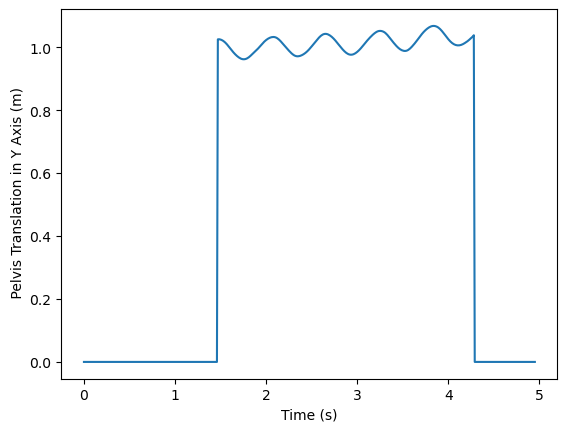

In [9]:
pelvis_ty = pelvis_4X4[2, 3]/1000  # Index 1 for y-axis, row 3 for translation, z for theia is y for global
plt.plot(time, pelvis_ty)
pelvis_ty = np.round(pelvis_ty,2)
plt.ylabel(" Pelvis Translation in Y Axis (m)")
plt.xlabel("Time (s)")
#plt.xlim(0,1.49)
#print(pelvis_ty)

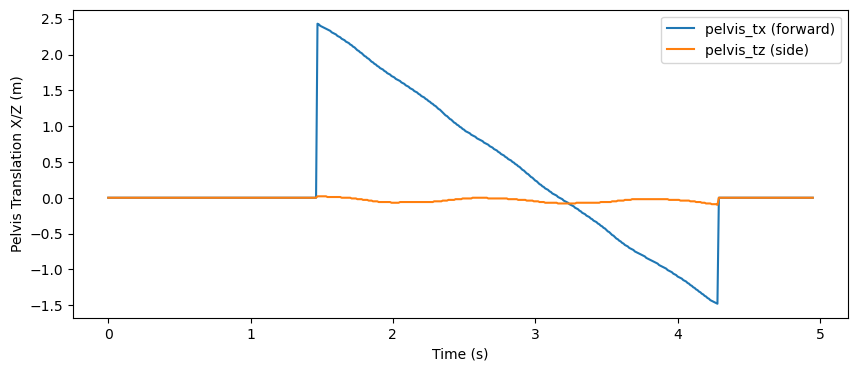

In [10]:
pelvis_tx = pelvis_4X4[1, 3] / 1000  # Theia Y → OpenSim X
pelvis_tz = pelvis_4X4[0, 3] / 1000  # Theia X → OpenSim Z
pelvis_tx = np.round(pelvis_tx, 2)
pelvis_tz = np.round(pelvis_tz, 2)

plt.figure(figsize=(10, 4))
plt.plot(time, pelvis_tx, label='pelvis_tx (forward)')
plt.plot(time, pelvis_tz, label='pelvis_tz (side)')
plt.ylabel("Pelvis Translation X/Z (m)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

In [ ]:
pelvistilt = pelvis_angles[0, 0, :]
plt.plot(time, pelvistilt)
plt.ylabel(" Pelvis Tilt Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvistilt = np.round(pelvistilt,2)

In [ ]:
pelvislist = pelvis_angles[1, 0, :]
plt.plot(time, pelvislist)
plt.ylabel(" Pelvis List Angle (deg)")
plt.xlabel("Time (s)")
plt.show()

pelvislist = np.round(pelvislist,2)

In [ ]:
torso_4X4 = get_segment_pose(c, 'torso_4X4')

# Lumbar motion is the torso relative to the pelvis.
lumbar_angles = relative_segment_angles(torso_4X4, pelvis_4X4)

In [ ]:
lumbarbending = lumbar_angles[0, 0, :]
plt.ylabel("Lumbar Bending Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarbending)
plt.show()

lumbarbending = np.round(lumbarbending,2)

In [ ]:
lumbarflex = lumbar_angles[1, 0, :]
plt.ylabel("Lumbar Flex/Extension (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarflex)
plt.show()

lumbarflex = np.round(lumbarflex,2)

In [ ]:
lumbarrot = lumbar_angles[2, 0, :]
plt.ylabel("Lumbar Rotation (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lumbarrot)
plt.show()

lumbarrot = np.round(lumbarrot,2)

In [ ]:
l_thigh_4X4 = get_segment_pose(c, 'l_thigh_4X4')
l_shank_4X4 = get_segment_pose(c, 'l_shank_4X4')

knee_angles_l = relative_segment_angles(l_thigh_4X4, l_shank_4X4)

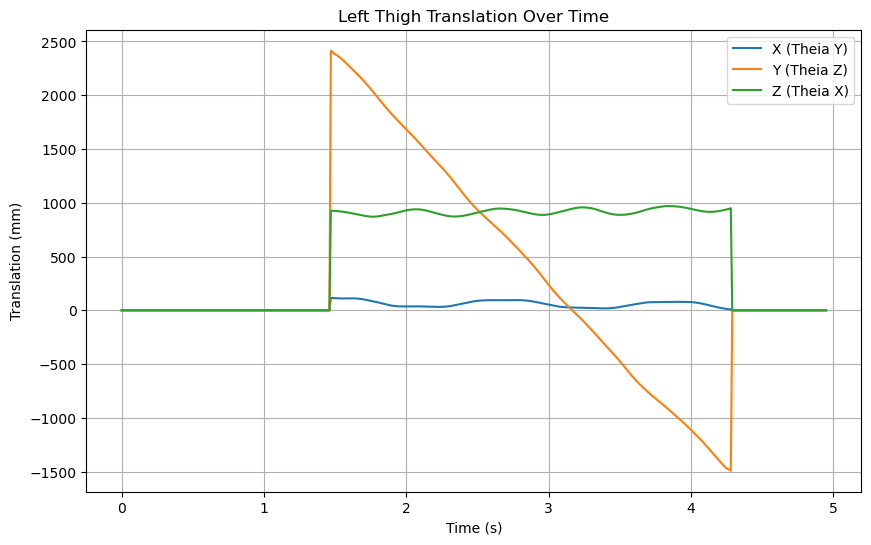

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Extract translations from l_thigh_4X4 (shape: [4, 4, N])
l_thigh_translations = l_thigh_4X4[:3, 3, :].T  # Shape: [N, 3] (x, y, z)

# Create a time array (assuming frame_rate and total_frames are defined)
time = np.arange(l_thigh_translations.shape[0]) / frame_rate

# Plot translations
plt.figure(figsize=(10, 6))
plt.plot(time, l_thigh_translations[:, 0], label='X (Theia Y)')
plt.plot(time, l_thigh_translations[:, 1], label='Y (Theia Z)')
plt.plot(time, l_thigh_translations[:, 2], label='Z (Theia X)')
plt.xlabel('Time (s)')
plt.ylabel('Translation (mm)')
plt.title('Left Thigh Translation Over Time')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
lkneeflex = knee_angles_l[0, 0, :]
plt.ylabel(" Left Knee Flexion/Extension Angle (deg)", fontsize=14)
plt.xlabel("Time (s)", fontsize=14)
plt.plot(time,lkneeflex)
plt.show()

lkneeflex = np.round(lkneeflex,2)

In [ ]:
lkneerot = knee_angles_l[1, 0, :]
plt.ylabel(" Left Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lkneerot)
plt.show()

lkneerot = np.round(lkneerot,2)

In [ ]:
lkneeadd = knee_angles_l[2, 0, :]
plt.ylabel(" Left Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time, lkneeadd)
plt.show()

lkneeadd = np.round(lkneeadd,2)

In [ ]:
r_thigh_4X4 = get_segment_pose(c, 'r_thigh_4X4')
r_shank_4X4 = get_segment_pose(c, 'r_shank_4X4')

knee_angles_r = relative_segment_angles(r_thigh_4X4, r_shank_4X4)

In [ ]:
rkneeflex = knee_angles_r[0, 0, :]
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Knee Flex/Ext (deg)")
plt.xlabel("Time (s)")
plt.plot(time, rkneeflex)
plt.show()
rkneeflex = np.round(rkneeflex, 2)

rkneerot = knee_angles_r[1, 0, :]
plt.ylabel(" Right Knee Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rkneerot)
plt.show()
rkneerot = np.round(rkneerot,2)

rkneeadd = knee_angles_r[2, 0, :]
plt.ylabel("Right Knee Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rkneeadd)
plt.show()
rkneeadd = np.round(rkneeadd,2)

In [ ]:
l_hip_angles = relative_segment_angles(pelvis_4X4, l_thigh_4X4)

In [ ]:
lhipflex = l_hip_angles[0, 0, :]
plt.ylabel("Left Hip Flex/Extension Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhipflex)
plt.show()
lhipflex = np.round(lhipflex,2)

In [ ]:
lhipadd = l_hip_angles[1, 0, :]
plt.ylabel("Left Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhipadd)
plt.show()
lhipadd = np.round(lhipadd,2)

In [ ]:
lhiprot = l_hip_angles[2, 0, :]
plt.ylabel("Left Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lhiprot)
plt.show()
lhiprot = np.round(lhiprot,2)

In [ ]:
r_hip_angles = relative_segment_angles(pelvis_4X4, r_thigh_4X4)

In [ ]:
rhipflex = r_hip_angles[0, 0, :]
plt.figure(figsize=(6, 2))  # Only applies to this plot
plt.ylabel("Right Hip Flex/Ext (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhipflex)
plt.show()
rhipflex = np.round(rhipflex,2)

In [ ]:
rhipadd = r_hip_angles[1, 0, :]
plt.ylabel("Right Hip Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhipadd)
plt.show()
rhipadd = np.round(rhipadd,2)

In [ ]:
rhiprot = r_hip_angles[2, 0, :]
plt.ylabel("Right Hip Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rhiprot)
plt.show()
rhiprot = np.round(rhiprot,2)

In [ ]:
l_foot_4X4 = get_segment_pose(c, 'l_foot_4X4')

ankle_angle_l = relative_segment_angles(l_shank_4X4, l_foot_4X4)

In [ ]:
lankleflex = ankle_angle_l[0, 0, :]
plt.ylabel("Left Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lankleflex)
plt.show()

lankleflex = np.round(lankleflex,2)

In [ ]:
lanklerot = ankle_angle_l[2, 0, :]
plt.ylabel("Left Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lanklerot)
plt.show()
lanklerot = np.round(lanklerot,2)

In [ ]:
lankleadd = ankle_angle_l[1, 0, :]
plt.ylabel("Left Ankle Add/Abd Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,lankleadd)
plt.show()
lankleadd = np.round(lankleadd,2)

In [ ]:
r_foot_4X4 = get_segment_pose(c, 'r_foot_4X4')

ankle_angle_r = relative_segment_angles(r_shank_4X4, r_foot_4X4)

In [ ]:
rankleflex = ankle_angle_r[0, 0, :]
plt.ylabel("Right Ankle Dorsi/Plantarflexion Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rankleflex)
plt.show()
rankleflex = np.round(rankleflex,2)

In [ ]:
ranklerot = ankle_angle_r[2, 0, :]
plt.ylabel("Right Ankle Int/External Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,ranklerot)
plt.show()
ranklerot = np.round(ranklerot,2)

In [ ]:
rankleadd = ankle_angle_r[1, 0, :]
plt.ylabel("Right Ankle Add/Abd Rotation Angle (deg)")
plt.xlabel("Time (s)")
plt.plot(time,rankleadd)
plt.show()
rankleadd = np.round(rankleadd,2)

In [ ]:
r_toes_4X4 = get_segment_pose(c, 'r_toes_4X4')
l_toes_4X4 = get_segment_pose(c, 'l_toes_4X4')

In [43]:
# Build the OpenSim-ready motion table from the calculated joint angles.
import pandas as pd

np.set_printoptions(suppress=True)

data = {
    'time': time, 
    'pelvis_list': pelvislist,
    'pelvis_rotation': pelvisrot,
    'pelvis_tilt': pelvistilt,	
    'hip_flexion_r': rhipflex,	
    'hip_adduction_r': rhipadd,	
    'hip_rotation_r': rhiprot,
    'knee_angle_r': rkneeflex,
    'ankle_angle_r': rankleflex,
    'hip_flexion_l': lhipflex,	
    'hip_adduction_l': lhipadd,
    'hip_rotation_l': lhiprot,
    'knee_angle_l': lkneeflex,
    'ankle_angle_l': lankleflex,
    'pelvis_tx': pelvis_tx,
    'pelvis_ty': pelvis_ty,
    'pelvis_tz': pelvis_tz,
    'lumbarbending': lumbarbending,
    'lumbar_rotation': lumbarrot,
    'lumbar_extension': lumbarflex
}

# Convert to a pandas DataFrame and make sure everything is numeric before export.
df = pd.DataFrame(data)
df = df.apply(pd.to_numeric, errors='coerce')

# OpenSim MOT headers must describe table size and time range.
header_lines = [
    "OS.mot",
    "version=1",
    "datacolumns " + str(df.shape[1]),
    "datarows " + str(df.shape[0]),
    "range 0 " + str(total_frames) ,
    "inDegrees=yes",
    "endheader"
 ]

# Write the header, then column names, then one row per time step.
with open('OS.mot', 'w') as f:
    # Write headers
    for line in header_lines:
        f.write(line + '\n')
    
    # Write column names
    f.write('\t'.join(df.columns) + '\n')  # Using tab (\t) for column separation

    # write each row in table order
    for row in df.itertuples(index=False, name=None):
        f.write('\t'.join(map(str, row)) + '\n')

#print(df.dtypes)

print("Data saved to OS.mot")

from IPython.display import FileLink

# Create a clickable link to the exported MOT file.
FileLink('OS.mot')

Data saved to OS.mot


e:\Xiong\Biomech\D_CO_Data\Queens U\theia2opensim\notebook\OS.mot

In [44]:
# Trim signals with leading or trailing zeros so the exported motion starts at movement.
import numpy as np
import pandas as pd
from IPython.display import FileLink

def trim_edges_zeros_and_reset_time(signal, frame_rate):
    signal = np.asarray(signal).flatten()
    non_zero_indices = np.nonzero(signal)[0]
    if non_zero_indices.size == 0:
        print("⚠️ Signal is all zeros — skipping.")
        return np.array([]), np.array([])
    
    start_idx = non_zero_indices[0]
    end_idx = non_zero_indices[-1] + 1
    trimmed_signal = signal[start_idx:end_idx]
    time_trimmed = np.arange(len(trimmed_signal)) / frame_rate
    return trimmed_signal, time_trimmed

def trim_and_export_mot(data, frame_rate, output_file='OS.mot'):
    trimmed_data = {}
    reference_time = None

    # Process each variable one by one so each signal can be trimmed independently.
    for key, signal in data.items():
        if key == 'time':
            continue
        trimmed_signal, trimmed_time = trim_edges_zeros_and_reset_time(signal, frame_rate)
        trimmed_data[key] = trimmed_signal

        # Keep the shortest valid time span so the final table stays rectangular.
        if reference_time is None or len(trimmed_time) < len(reference_time):
            reference_time = trimmed_time

    # Re-align all signals to match the same time length before export.
    for key in trimmed_data:
        trimmed_data[key] = trimmed_data[key][:len(reference_time)]
    trimmed_data['time'] = reference_time

    # Ensure 'time' is the first column in the exported MOT file.
    ordered_columns = ['time'] + [k for k in trimmed_data if k != 'time']
    df = pd.DataFrame({col: trimmed_data[col] for col in ordered_columns})

    # Write the OpenSim MOT header and then the motion table.
    header_lines = [
        "OS.mot",
        "version=1",
        f"datacolumns {df.shape[1]}",
        f"datarows {df.shape[0]}",
        f"range {reference_time[0]:.5f} {reference_time[-1]:.5f}",
        "inDegrees=yes",
        "endheader"
    ]

    with open(output_file, 'w') as f:
        for line in header_lines:
            f.write(line + '\n')
        f.write('\t'.join(df.columns) + '\n')
        for row in df.itertuples(index=False, name=None):
            f.write('\t'.join(map(lambda x: f"{x:.6f}", row)) + '\n')

    print(f"✅ Trimmed .mot file saved to: {output_file}")
    return FileLink(output_file)

trim_and_export_mot(data, frame_rate, output_file='OS.mot')

✅ Trimmed .mot file saved to: OS.mot


e:\Xiong\Biomech\D_CO_Data\Queens U\theia2opensim\notebook\OS.mot

In [ ]:
# Build the static .trc file using the resolved static source (c_static, set in
# the USER SETUP / dynamic-trial-selection cells above) and select_frame set at
# the top. This reuses workflow_utils.write_static_trc_from_c3d instead of the
# hand-rolled column layout used here previously, so the marker set/axis mapping
# stays in lockstep with the rest of the pipeline.
static_frame_indices = [select_frame]

write_static_trc_from_c3d(
    c_static,
    output_path='static1.trc',
    frame_indices=static_frame_indices,
)

FileLink('static1.trc')

In [46]:
import numpy as np
from scipy.io import savemat

# Assuming the following 4x4 matrices are defined in your code:
# pelvis_4X4, r_thigh_4X4, l_thigh_4X4, r_shank_4X4, l_shank_4X4, r_foot_4X4, l_foot_4X4, r_toes_4X4, l_toes_4X4

# Extract translations for all frames (not just frame 300)
joint_centers = {
    'PELVIS': pelvis_4X4[:3, 3, :].T,  # Shape: [N, 3] (x, y, z)
    'RFEMUR': r_thigh_4X4[:3, 3, :].T,   # Right ASIS
    'LFEMUR': l_thigh_4X4[:3, 3, :].T,   # Left ASIS
    'RTIB': r_shank_4X4[:3, 3, :].T,   # Right knee
    'LTIB': l_shank_4X4[:3, 3, :].T,   # Left knee
    'RFOOT': r_foot_4X4[:3, 3, :].T,   # Right ankle
    'LFOOT': l_foot_4X4[:3, 3, :].T,   # Left ankle
    'RTOE': r_toes_4X4[:3, 3, :].T,     # Right toe
    'LTOE': l_toes_4X4[:3, 3, :].T,     # Left toe
}

# Save to a .mat file
savemat('joint_centers.mat', joint_centers)

print("Joint centers saved to 'joint_centers.mat'")


Joint centers saved to 'joint_centers.mat'
